1. Title and objective

# CICIoMT2024 - Data Loading and Initial Inspection

## Objective
The purpose of this notebook is to load the CICIoMT2024 dataset, merge the raw CSV files, inspect their structure, verify the target variables, assess class imbalance, and identify initial data quality issues such as missing values, duplicates, and infinite values.

This notebook establishes the foundation for the preprocessing, exploratory data analysis, and machine learning stages of the project.

2. Imports

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

3. Display settings

In [17]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)

4. Define dataset path

In [18]:
DATA_DIR = Path("../data/raw")
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")
[file.name for file in csv_files]

Number of CSV files found: 15


['Benign Traffic.csv',
 'DDoS ICMP Flood.csv',
 'DDoS UDP Flood.csv',
 'DoS ICMP Flood.csv',
 'DoS TCP Flood.csv',
 'DoS UDP Flood.csv',
 'MITM ARP Spoofing.csv',
 'MQTT DDoS Publish Flood.csv',
 'MQTT DoS Connect Flood.csv',
 'MQTT DoS Publish Flood.csv',
 'MQTT Malformed.csv',
 'Recon OS Scan.csv',
 'Recon Ping Sweep.csv',
 'Recon Port Scan.csv',
 'Recon Vulnerability Scan.csv']

5. Inspect file names and file sizes

## File inventory
This section lists all available raw CSV files and their sizes.

In [19]:
file_info = []

for file in csv_files:
    file_info.append({
        "file_name": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

file_info_df = pd.DataFrame(file_info).sort_values("file_name").reset_index(drop=True)
file_info_df

,file_name,size_mb
0,Benign Traffic.csv,21.14
1,DDoS ICMP Flood.csv,1.63
2,DDoS UDP Flood.csv,1.60
3,DoS ICMP Flood.csv,1.36
4,DoS TCP Flood.csv,1054.66
5,DoS UDP Flood.csv,1.91
6,MITM ARP Spoofing.csv,0.67
7,MQTT DDoS Publish Flood.csv,191.54
8,MQTT DoS Connect Flood.csv,135.77
9,MQTT DoS Publish Flood.csv,0.67


6. Load one sample file for initial inspection

## Sample file inspection
A single file is loaded first to inspect the schema, feature names, and data types.

In [20]:
sample_file = DATA_DIR / "Benign Traffic.csv"
df_sample = pd.read_csv(sample_file)

print("Sample shape:", df_sample.shape)
df_sample.head()

Sample shape: (32620, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
0,34.173.20.6-192.168.137.234-443-58644-6,34.173.20.6,443,192.168.137.234,58644,6,14/09/2023 09:24:26 AM,14746364,6,0,63.0,0.0,39.0,0.0,10.500000,16.944025,0.0,0.0,0.00000,0.000000,4.272240,0.406880,2.949273e+06,6.558360e+06,14681116.0,2.0,14746364.0,2.949273e+06,6.558360e+06,14681116.0,2.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,192,0,0.406880,0.000000,0.0,39.0,9.000000,15.968719,255.000000,1,0,1,2,6,0,0,0,0.0,10.500000,10.500000,0.00000,0,0,0,0,0,0,6,63,0,0,331,0,2,32,0.0,0.0,0.0,0.0,14681116.0,0.000000,14681116.0,14681116.0,Benign Traffic,0
1,34.173.20.6-192.168.137.234-443-58646-6,34.173.20.6,443,192.168.137.234,58646,6,14/09/2023 09:24:41 AM,60102110,18,0,4135.0,0.0,1408.0,0.0,229.722222,490.460505,0.0,0.0,0.00000,0.000000,68.799581,0.299490,3.535418e+06,6.531527e+06,15061923.0,1.0,60102110.0,3.535418e+06,6.531527e+06,15061923.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,584,0,0.299490,0.000000,0.0,1408.0,217.631579,479.546685,229965.023392,1,1,1,7,18,0,0,0,0.0,229.722222,229.722222,0.00000,0,0,0,4072,6,56313,4,1033,0,0,43648,0,8,32,219123.0,0.0,219123.0,219123.0,14957706.0,190543.248665,15061923.0,14672051.0,Benign Traffic,0
2,52.40.210.103-192.168.137.40-18665-60378-6,52.40.210.103,18665,192.168.137.40,60378,6,14/09/2023 09:24:14 AM,90106769,9,0,1164.0,0.0,194.0,0.0,129.333333,97.000000,0.0,0.0,0.00000,0.000000,12.918008,0.099882,1.126335e+07,1.538550e+07,30049066.0,4.0,90106769.0,1.126335e+07,1.538550e+07,30049066.0,4.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,312,0,0.099882,0.000000,0.0,194.0,135.800000,93.710903,8781.733333,0,0,0,6,9,0,0,0,0.0,150.888889,129.333333,0.00000,0,0,0,0,0,0,3,388,0,0,850,0,5,32,582529.0,0.0,582529.0,582529.0,29841412.0,319090.538141,30049066.0,29473997.0,Benign Traffic,0
3,10.0.0.3-10.0.0.254-44505-1883-6,10.0.0.3,44505,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998980,123,123,2157.0,4.0,20.0,0.0,17.536585,2.309257,2.0,0.0,0.03252,0.253983,18.008486,2.050017,4.897918e+05,5.001567e+05,1008475.0,29.0,119998868.0,9.835973e+05,1.271666e+05,1008531.0,2539.0,119998918.0,983597.688525,127738.757478,1042745.0,104.0,1,0,0,0,3936,3936,1.025009,1.025009,0.0,20.0,8.821862,8.922922,79.618544,0,0,0,123,246,0,0,0,1.0,8.857724,17.536585,0.03252,0,0,0,72,4,24,2,38,2,0,502,64,120,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,0
4,10.0.0.7-10.0.0.254-45727-1883-6,10.0.0.7,45727,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998539,123,123,5411.0,4.0,46.0,0.0,43.991870,5.699433,2.0,0.0,0.03252,0.253983,45.125549,2.050025,4.897900e+05,5.001719e+05,1007898.0,9.0,119998518.0,9.835944e+05,1.273177e+05,1007992.0,1432.0,119998515.0,983594.385246,127764.337251,1043184.0,78.0,1,0,0,0,3936,3936,1.025012,1.025012,0.0,46.0

7. Inspect column names

In [21]:
df_sample.columns.tolist()

['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'R

8. Inspect data types and missing values in the sample

In [22]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32620 entries, 0 to 32619
Data columns (total 85 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Flow ID                     32620 non-null  object 
 1   Src IP                      32620 non-null  object 
 2   Src Port                    32620 non-null  int64  
 3   Dst IP                      32620 non-null  object 
 4   Dst Port                    32620 non-null  int64  
 5   Protocol                    32620 non-null  int64  
 6   Timestamp                   32620 non-null  object 
 7   Flow Duration               32620 non-null  int64  
 8   Total Fwd Packet            32620 non-null  int64  
 9   Total Bwd packets           32620 non-null  int64  
 10  Total Length of Fwd Packet  32620 non-null  float64
 11  Total Length of Bwd Packet  32620 non-null  float64
 12  Fwd Packet Length Max       32620 non-null  float64
 13  Fwd Packet Length Min       326

In [23]:
df_sample.isna().sum().sort_values(ascending=False).head(20)

Flow ID                       0
Src IP                        0
Src Port                      0
Dst IP                        0
Dst Port                      0
Protocol                      0
Timestamp                     0
Flow Duration                 0
Total Fwd Packet              0
Total Bwd packets             0
Total Length of Fwd Packet    0
Total Length of Bwd Packet    0
Fwd Packet Length Max         0
Fwd Packet Length Min         0
Fwd Packet Length Mean        0
Fwd Packet Length Std         0
Bwd Packet Length Max         0
Bwd Packet Length Min         0
Bwd Packet Length Mean        0
Bwd Packet Length Std         0
dtype: int64

9. Check whether all files have the same structure

## Schema consistency check
This step verifies whether all CSV files share the same columns in the same order.

In [24]:
columns_dict = {}

for file in csv_files:
    df_temp = pd.read_csv(file, nrows=5)
    columns_dict[file.name] = df_temp.columns.tolist()

first_file = list(columns_dict.keys())[0]
base_cols = columns_dict[first_file]

same_structure = {}

for fname, cols in columns_dict.items():
    same_structure[fname] = (cols == base_cols)

schema_check_df = pd.DataFrame.from_dict(
    same_structure,
    orient="index",
    columns=["same_columns_as_first_file"]
).reset_index().rename(columns={"index": "file_name"})

schema_check_df

,file_name,same_columns_as_first_file
0,Benign Traffic.csv,True
1,DDoS ICMP Flood.csv,True
2,DDoS UDP Flood.csv,True
3,DoS ICMP Flood.csv,True
4,DoS TCP Flood.csv,True
5,DoS UDP Flood.csv,True
6,MITM ARP Spoofing.csv,True
7,MQTT DDoS Publish Flood.csv,True
8,MQTT DoS Connect Flood.csv,True
9,MQTT DoS Publish Flood.csv,True


In [25]:
schema_check_df["same_columns_as_first_file"].value_counts()

same_columns_as_first_file
True    15
Name: count, dtype: int64

10. Load and merge all CSV files

## Merge all raw files
All CSV files are now loaded and merged into a single dataframe.

In [26]:
all_dfs = []

for file in csv_files:
    df_temp = pd.read_csv(file)
    df_temp["source_file"] = file.name
    all_dfs.append(df_temp)

df = pd.concat(all_dfs, ignore_index=True)

print("Full dataset shape:", df.shape)
df.head()

Full dataset shape: (3385313, 86)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label,source_file
0,34.173.20.6-192.168.137.234-443-58644-6,34.173.20.6,443,192.168.137.234,58644,6,14/09/2023 09:24:26 AM,14746364,6,0,63.0,0.0,39.0,0.0,10.500000,16.944025,0.0,0.0,0.00000,0.000000,4.272240,0.406880,2.949273e+06,6.558360e+06,14681116.0,2.0,14746364.0,2.949273e+06,6.558360e+06,14681116.0,2.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,192,0,0.406880,0.000000,0.0,39.0,9.000000,15.968719,255.000000,1,0,1,2,6,0,0,0,0.0,10.500000,10.500000,0.00000,0,0,0,0,0,0,6,63,0,0,331,0,2,32,0.0,0.0,0.0,0.0,14681116.0,0.000000,14681116.0,14681116.0,Benign Traffic,0,Benign Traffic.csv
1,34.173.20.6-192.168.137.234-443-58646-6,34.173.20.6,443,192.168.137.234,58646,6,14/09/2023 09:24:41 AM,60102110,18,0,4135.0,0.0,1408.0,0.0,229.722222,490.460505,0.0,0.0,0.00000,0.000000,68.799581,0.299490,3.535418e+06,6.531527e+06,15061923.0,1.0,60102110.0,3.535418e+06,6.531527e+06,15061923.0,1.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,584,0,0.299490,0.000000,0.0,1408.0,217.631579,479.546685,229965.023392,1,1,1,7,18,0,0,0,0.0,229.722222,229.722222,0.00000,0,0,0,4072,6,56313,4,1033,0,0,43648,0,8,32,219123.0,0.0,219123.0,219123.0,14957706.0,190543.248665,15061923.0,14672051.0,Benign Traffic,0,Benign Traffic.csv
2,52.40.210.103-192.168.137.40-18665-60378-6,52.40.210.103,18665,192.168.137.40,60378,6,14/09/2023 09:24:14 AM,90106769,9,0,1164.0,0.0,194.0,0.0,129.333333,97.000000,0.0,0.0,0.00000,0.000000,12.918008,0.099882,1.126335e+07,1.538550e+07,30049066.0,4.0,90106769.0,1.126335e+07,1.538550e+07,30049066.0,4.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,312,0,0.099882,0.000000,0.0,194.0,135.800000,93.710903,8781.733333,0,0,0,6,9,0,0,0,0.0,150.888889,129.333333,0.00000,0,0,0,0,0,0,3,388,0,0,850,0,5,32,582529.0,0.0,582529.0,582529.0,29841412.0,319090.538141,30049066.0,29473997.0,Benign Traffic,0,Benign Traffic.csv
3,10.0.0.3-10.0.0.254-44505-1883-6,10.0.0.3,44505,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998980,123,123,2157.0,4.0,20.0,0.0,17.536585,2.309257,2.0,0.0,0.03252,0.253983,18.008486,2.050017,4.897918e+05,5.001567e+05,1008475.0,29.0,119998868.0,9.835973e+05,1.271666e+05,1008531.0,2539.0,119998918.0,983597.688525,127738.757478,1042745.0,104.0,1,0,0,0,3936,3936,1.025009,1.025009,0.0,20.0,8.821862,8.922922,79.618544,0,0,0,123,246,0,0,0,1.0,8.857724,17.536585,0.03252,0,0,0,72,4,24,2,38,2,0,502,64,120,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,0,Benign Traffic.csv
4,10.0.0.7-10.0.0.254-45727-1883-6,10.0.0.7,45727,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998539,123,123,5411.0,4.0,46.0,0.0,43.991870,5.699433,2.0,0.0,0.03252,0.253983,45.125549,2.050025,4.897900e+05,5.001719e+05,1007898.0,9.0,119998518.0,9.835944e+05,1.273177e+05,1007992.0,1432.0,119998515.0

11. Confirm key target columns

## Target column verification
The dataset includes two important target-related columns:

- `Label`: binary target for benign vs attack
- `Attack Name`: detailed multiclass attack label

In [27]:
print("Columns in merged dataset:")
print(df.columns.tolist())

Columns in merged dataset:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Fla

In [28]:
print("Unique values in Label:")
print(df["Label"].unique())

print("\nNumber of unique Attack Name values:")
print(df["Attack Name"].nunique())

Unique values in Label:
[0 1]

Number of unique Attack Name values:
15


In [29]:
print("Label distribution:")
print(df["Label"].value_counts(dropna=False))

print("\nAttack Name distribution:")
print(df["Attack Name"].value_counts(dropna=False))

Label distribution:
Label
1    3352693
0      32620
Name: count, dtype: int64

Attack Name distribution:
Attack Name
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64


12. Create working label column

## Working label column
A working label column is created for convenience using the detailed attack label.

In [30]:
df["attack_label"] = df["Attack Name"].copy()
df["attack_label"].value_counts()

attack_label
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64

13. Create grouped attack categories

## Grouped attack categories
To support a more interpretable multiclass task, detailed attack labels are grouped into broader categories.

In [31]:
def map_attack_category(label):
    if label == "Benign Traffic":
        return "Benign"
    elif label.startswith("DDoS"):
        return "DDoS"
    elif label.startswith("DoS"):
        return "DoS"
    elif label.startswith("MQTT"):
        return "MQTT Attack"
    elif label.startswith("Recon"):
        return "Recon"
    elif "MITM" in label or "Spoofing" in label:
        return "Spoofing"
    else:
        return "Other"

In [32]:
df["attack_category"] = df["attack_label"].apply(map_attack_category)
df["attack_category"].value_counts()

attack_category
DoS            2112138
MQTT Attack     655143
Recon           579231
Benign           32620
DDoS              5128
Spoofing          1053
Name: count, dtype: int64

14. Create binary target

## Binary target
The binary target is created as:

- 0 = Benign
- 1 = Attack

In [33]:
df["target_binary"] = (df["attack_label"] != "Benign Traffic").astype(int)
df["target_binary"].value_counts()

target_binary
1    3352693
0      32620
Name: count, dtype: int64

15. Create multiclass targets

In [34]:
df["target_multiclass_full"] = df["attack_label"]
df["target_multiclass_grouped"] = df["attack_category"]

In [35]:
print("Full multiclass distribution:")
print(df["target_multiclass_full"].value_counts())

print("\nGrouped multiclass distribution:")
print(df["target_multiclass_grouped"].value_counts())

Full multiclass distribution:
target_multiclass_full
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64

Grouped multiclass distribution:
target_multiclass_grouped
DoS            2112138
MQTT Attack     655143
Recon           579231
Benign           32620
DDoS              5128
Spoofing          1053
Name: count, dtype: int64


16. Dataset quality checks

## Data quality checks
This section evaluates duplicates, missing values, and infinite values.

In [36]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 109180


In [37]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_column[missing_by_column > 0].head(30)
total_missing = df.isna().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


In [38]:
numeric_df = df.select_dtypes(include=[np.number])
total_infinite = np.isinf(numeric_df).sum().sum()

print("Number of numeric columns:", numeric_df.shape[1])
print("Total infinite values:", total_infinite)

Number of numeric columns: 81
Total infinite values: 0


In [39]:
inf_per_column = pd.Series(np.isinf(numeric_df).sum(), index=numeric_df.columns).sort_values(ascending=False)
inf_per_column[inf_per_column > 0].head(30)

Series([], dtype: int64)

17. Quick feature summary

## Feature summary
This section separates features from targets and reports the number of candidate predictors.

In [40]:
target_cols = [
    "Label",
    "Attack Name",
    "attack_label",
    "attack_category",
    "target_binary",
    "target_multiclass_full",
    "target_multiclass_grouped",
    "source_file"
]

feature_cols = [col for col in df.columns if col not in target_cols]

print("Total number of columns:", df.shape[1])
print("Number of target / metadata columns:", len(target_cols))
print("Number of candidate feature columns:", len(feature_cols))

Total number of columns: 91
Number of target / metadata columns: 8
Number of candidate feature columns: 83


In [41]:
feature_cols[:20]

['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std']

18. Class distribution plots

## Class distribution plots
The following plots illustrate the class imbalance in the binary and multiclass targets.

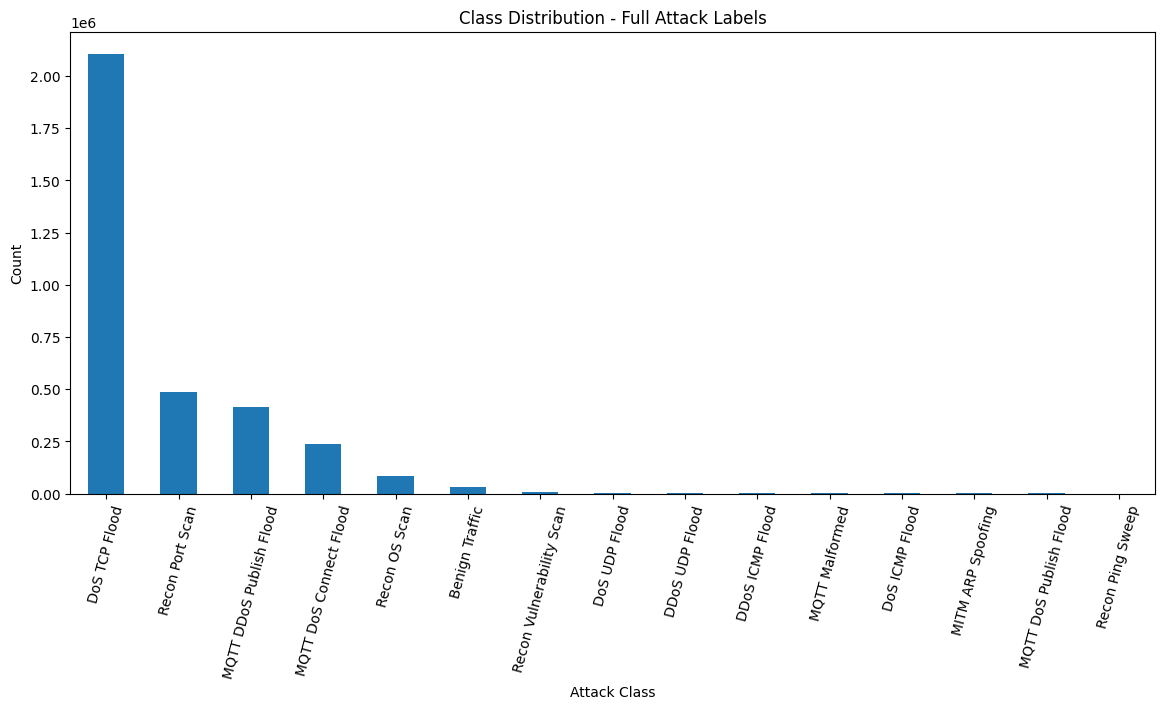

In [42]:
df["target_multiclass_full"].value_counts().plot(kind="bar", figsize=(14, 6))
plt.title("Class Distribution - Full Attack Labels")
plt.ylabel("Count")
plt.xlabel("Attack Class")
plt.xticks(rotation=75)
plt.show()

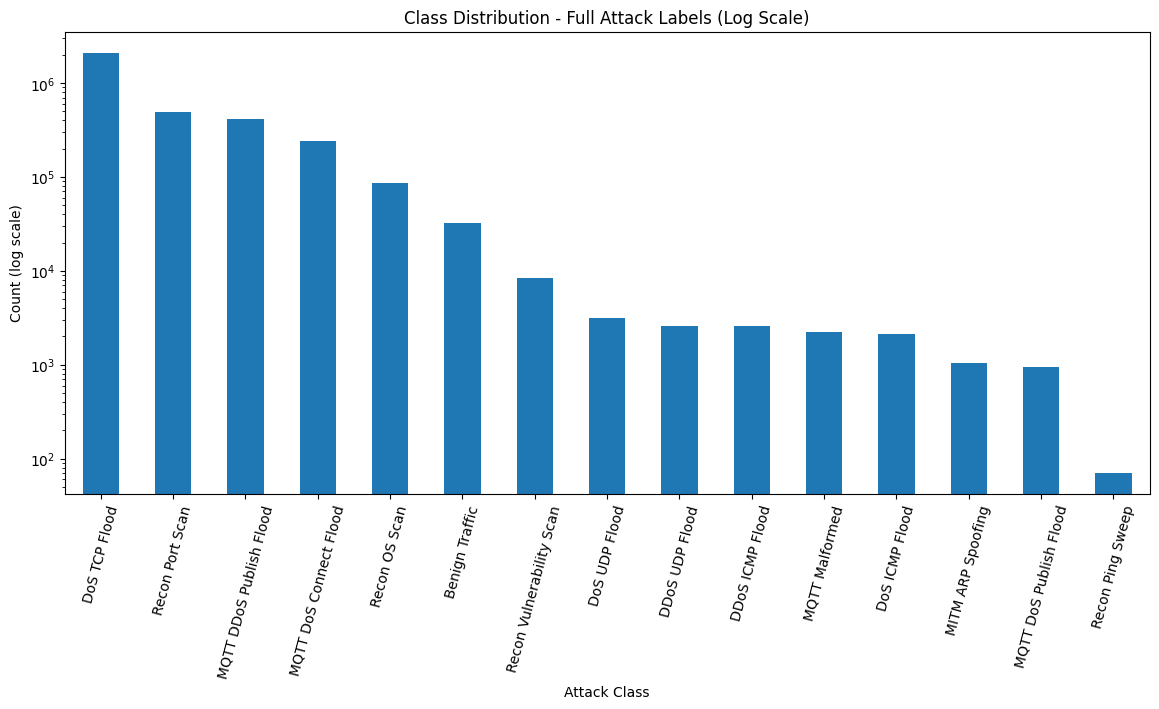

In [43]:
df["target_multiclass_full"].value_counts().plot(kind="bar", figsize=(14, 6), logy=True)
plt.title("Class Distribution - Full Attack Labels (Log Scale)")
plt.ylabel("Count (log scale)")
plt.xlabel("Attack Class")
plt.xticks(rotation=75)
plt.show()

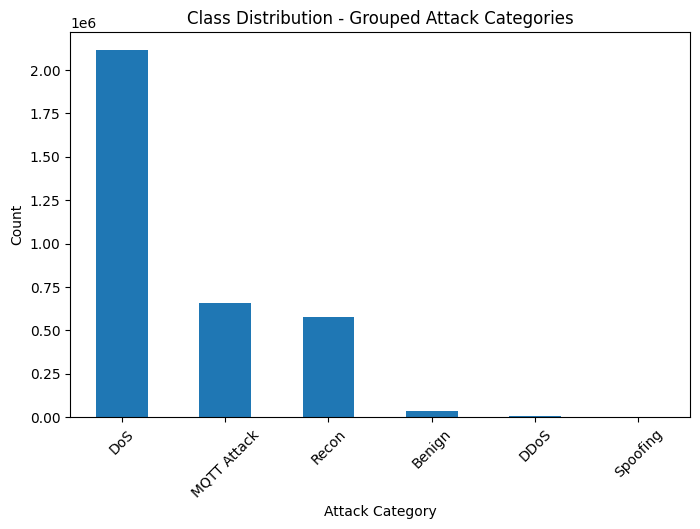

In [44]:
df["target_multiclass_grouped"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution - Grouped Attack Categories")
plt.ylabel("Count")
plt.xlabel("Attack Category")
plt.xticks(rotation=45)
plt.show()

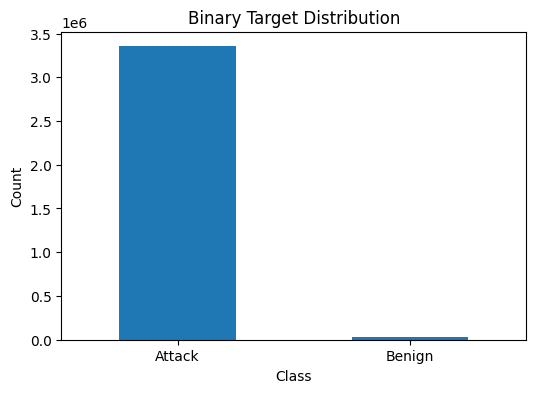

In [45]:
binary_plot_series = df["target_binary"].map({0: "Benign", 1: "Attack"})
binary_plot_series.value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Binary Target Distribution")
plt.ylabel("Count")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.show()

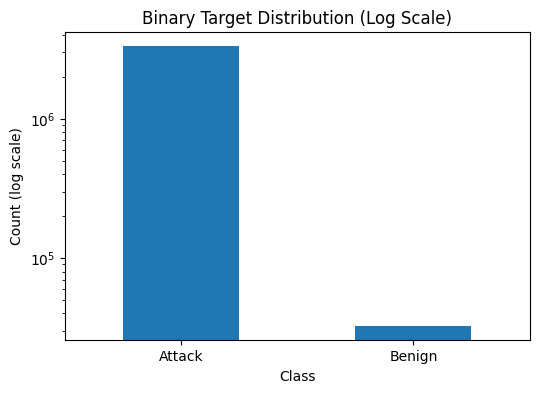

In [46]:
binary_plot_series.value_counts().plot(kind="bar", figsize=(6, 4), logy=True)
plt.title("Binary Target Distribution (Log Scale)")
plt.ylabel("Count (log scale)")
plt.xlabel("Class")
plt.xticks(rotation=0)
plt.show()

19. Class proportion tables

In [47]:
binary_distribution = df["target_binary"].value_counts().rename_axis("class").reset_index(name="count")
binary_distribution["percentage"] = (binary_distribution["count"] / binary_distribution["count"].sum()) * 100
binary_distribution

,class,count,percentage
0,1,3352693,99.036426
1,0,32620,0.963574


In [48]:
grouped_distribution = df["target_multiclass_grouped"].value_counts().rename_axis("class").reset_index(name="count")
grouped_distribution["percentage"] = (grouped_distribution["count"] / grouped_distribution["count"].sum()) * 100
grouped_distribution

,class,count,percentage
0,DoS,2112138,62.391218
1,MQTT Attack,655143,19.352509
2,Recon,579231,17.110117
3,Benign,32620,0.963574
4,DDoS,5128,0.151478
5,Spoofing,1053,0.031105


In [49]:
full_distribution = df["target_multiclass_full"].value_counts().rename_axis("class").reset_index(name="count")
full_distribution["percentage"] = (full_distribution["count"] / full_distribution["count"].sum()) * 100
full_distribution

,class,count,percentage
0,DoS TCP Flood,2106916,62.236963
1,Recon Port Scan,485522,14.342012
2,MQTT DDoS Publish Flood,413913,12.226728
3,MQTT DoS Connect Flood,238031,7.031285
4,Recon OS Scan,85317,2.520210
5,Benign Traffic,32620,0.963574
6,Recon Vulnerability Scan,8321,0.245797
7,DoS UDP Flood,3115,0.092015
8,DDoS UDP Flood,2576,0.076093
9,DDoS ICMP Flood,2552,0.075384


In [50]:
binary_mapping_df = pd.DataFrame({
    "target_binary_value": [0, 1],
    "meaning": ["Benign", "Attack"]
})

binary_mapping_df

,target_binary_value,meaning
0,0,Benign
1,1,Attack


20. Save merged dataset for later notebooks

## Save interim dataset
The merged dataset is saved for reuse in subsequent notebooks.

In [52]:
INTERIM_DIR = Path("../data/interim")
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

output_path = INTERIM_DIR / "ciciomt2024_merged.csv"
df.to_csv(output_path, index=False)

print(f"Saved merged dataset to: {output_path}")

Saved merged dataset to: ..\data\interim\ciciomt2024_merged.csv


21. Final summary for Notebook 1

The dataset was successfully loaded and merged across all attack-specific CSV files. It contains 81 numeric predictors and target-related columns for both binary and multiclass classification. Initial data-quality checks showed no missing values and no infinite values, indicating a structurally clean dataset. However, severe class imbalance was observed, particularly in the binary target and the detailed attack classes, which will require class-sensitive evaluation in subsequent modeling.